In [1]:
import os
import sys
from ipywidgets import interact

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_notebook import *

%matplotlib widget

In [2]:
project_name = "syn"
condition = "debug"
data = "test1"
switch_epoch = 10000

checkpoint_epoch=0

n_samples = 32
show_results_fusion = False
fusion_attr_weight = 1.0
noise = 0.0

project_name = "syn"
experiment_name = get_experiment_name(condition, data, switch_epoch)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

global_workspace = get_global_workspace(project_name, experiment_name, epoch=checkpoint_epoch)
visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods["v_latents"])
data_module = get_data_module(project_name,  experiment_name)

data_module.setup()

Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/debug_test1_switch_10000/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/debug_test1_switch_10000/checkpoints/last.ckpt


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [3]:
def get_centroid(mask):
    """
    Calcule le centre de masse avec :
    - x, y normalisés entre -1 et 1
    - (1, 1) correspondant au coin HAUT-DROITE
    """
    B, _, H, W = mask.shape
    device = mask.device
    
    # 1. Création des grilles de -1 à 1
    # Pour x : de gauche (-1) à droite (1)
    # Pour y : de bas (-1) à haut (1) -> on inverse l'ordre de linspace
    grid_x = torch.linspace(-1, 1, W, device=device)
    grid_y = torch.linspace(1, -1, H, device=device) # Inversion ici : le haut est 1
    
    mesh_y, mesh_x = torch.meshgrid(grid_y, grid_x, indexing='ij')
    
    # 2. Calcul de la masse totale
    total_mass = mask.sum(dim=(2, 3)) + 1e-8
    
    # 3. Pondération par les intensités du masque
    # (B, 1, H, W) * (H, W) -> Somme sur H, W -> (B, 1)
    pos_x = (mask * mesh_x).sum(dim=(2, 3)) / total_mass
    pos_y = (mask * mesh_y).sum(dim=(2, 3)) / total_mass
    
    # 4. Retourne (B, 2)
    return torch.cat([pos_x, pos_y], dim=1)

def get_mask(images, temperature=100.0):
    # On binarise fort pour éviter le flou central
    grayscale = images.mean(dim=1, keepdim=True)
    return torch.sigmoid((grayscale - 0.1) * temperature)


def get_area(tensor):
    area = tensor.sum(dim=(1, 2, 3))
    area_norm = (area - 25) / (128 - 25 + 1e-8)
    return torch.clamp(area_norm, 0.0, 1.0)


In [4]:
samples = data_module.get_samples('train', 10)

In [5]:
idx = 0

imgs_latent = samples[frozenset({'v_latents'})]["v_latents"].to(device)
imgs_tensor = visual_module.decode_images(imgs_latent)
img_tensor = imgs_tensor[idx]
img_np = img_tensor.permute(1, 2, 0).detach().cpu().numpy()

{'attr': [tensor([[1, 0, 0],
        [0, 1, 0],
        [1, 0, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 0, 1],
        [1, 0, 0],
        [0, 0, 1],
        [1, 0, 0],
        [1, 0, 0]]), tensor([[-0.8889, -0.8889,  1.0000,  0.5482, -0.8364],
        [-0.2222,  0.0000, -1.0000, -0.6021, -0.7985],
        [-0.6667, -0.3333, -0.7143,  0.5432, -0.8396],
        [ 0.2222,  0.5556, -0.7143, -0.0924,  0.9957],
        [-1.0000,  0.5556, -0.7143, -0.8009,  0.5988],
        [-0.6667,  0.3333,  1.0000, -0.9454, -0.3258],
        [ 0.1111,  0.2222, -1.0000,  0.5094,  0.8606],
        [-0.5556, -0.3333,  1.0000, -0.6837,  0.7298],
        [-0.5556,  0.6667, -0.4286,  0.6057,  0.7957],
        [-0.6667,  0.3333,  0.1429, -0.9058, -0.4236]])]}


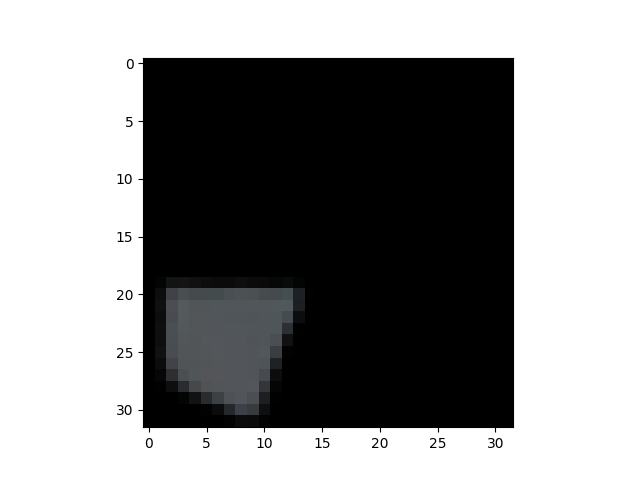

In [6]:
plt.imshow(img_np)
print(samples[frozenset({'attr'})])
plt.show()

In [7]:
masks = get_mask(imgs_tensor)
centroids = get_centroid(masks)
area = get_area(masks)

In [8]:
print(samples[frozenset({'attr'})]['attr'])

print(area)

[tensor([[1, 0, 0],
        [0, 1, 0],
        [1, 0, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 0, 1],
        [1, 0, 0],
        [0, 0, 1],
        [1, 0, 0],
        [1, 0, 0]]), tensor([[-0.8889, -0.8889,  1.0000,  0.5482, -0.8364],
        [-0.2222,  0.0000, -1.0000, -0.6021, -0.7985],
        [-0.6667, -0.3333, -0.7143,  0.5432, -0.8396],
        [ 0.2222,  0.5556, -0.7143, -0.0924,  0.9957],
        [-1.0000,  0.5556, -0.7143, -0.8009,  0.5988],
        [-0.6667,  0.3333,  1.0000, -0.9454, -0.3258],
        [ 0.1111,  0.2222, -1.0000,  0.5094,  0.8606],
        [-0.5556, -0.3333,  1.0000, -0.6837,  0.7298],
        [-0.5556,  0.6667, -0.4286,  0.6057,  0.7957],
        [-0.6667,  0.3333,  0.1429, -0.9058, -0.4236]])]
tensor([0.7516, 0.1209, 0.1580, 0.1997, 0.1962, 0.4211, 0.0196, 0.4545, 0.2036,
        0.4542], device='cuda:0')


In [9]:
def plot_debug_batch(x_target, target_pos, x_pred, pred_pos, n_samples=4):
    """
    Affiche une comparaison visuelle avec les centroïdes.
    Rouge = Cible (Target), Vert = Prédiction (Mapper)
    """
    x_target = x_target.detach().cpu()
    x_pred = x_pred.detach().cpu()
    target_pos = target_pos.detach().cpu()
    pred_pos = pred_pos.detach().cpu()

    B, C, H, W = x_target.shape
    n_samples = min(n_samples, B)

    fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 3, 6))
    
    for i in range(n_samples):
        # Conversion des coordonnées (-1, 1) -> Pixels (0, H ou W)
        # Rappel : y=1 est le haut, donc y_px = (1 - y) / 2 * H
        t_x = (target_pos[i, 0] + 1) / 2 * W
        t_y = (1 - target_pos[i, 1]) / 2 * H
        p_x = (pred_pos[i, 0] + 1) / 2 * W
        p_y = (1 - pred_pos[i, 1]) / 2 * H

        # Affichage Target
        img_t = x_target[i].mean(0) if C > 1 else x_target[i, 0]
        axes[0, i].imshow(img_t, cmap='gray')
        axes[0, i].scatter(t_x, t_y, color='red', s=40, label='GT')
        axes[0, i].set_title(f"Target {i}")
        axes[0, i].axis('off')

        # Affichage Prediction
        img_p = x_pred[i].mean(0) if C > 1 else x_pred[i, 0]
        axes[1, i].imshow(img_p, cmap='gray')
        axes[1, i].scatter(p_x, p_y, color='lime', s=40, label='Pred')
        axes[1, i].set_title(f"Mapper {i}")
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

class SimpleMapper(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 32),
            nn.LeakyReLU(0.1),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)

def train(visual_module, dataloader, num_epochs=20):
    device = next(visual_module.parameters()).device
    visual_module.eval()

    mapper = SimpleMapper().to(device)
    optimizer = optim.Adam(mapper.parameters(), lr=1e-3)

    for epoch in range(num_epochs):
        mapper.train()
        total_loss = 0.0

        for batch in dataloader:
            images_raw = batch[0][frozenset({'attr', 'v_latents'})]['v_latents'].to(device)
            attr_dict = batch[0][frozenset({'attr', 'v_latents'})]['attr']
            attr_combined = torch.cat([attr_dict[0].to(device), attr_dict[1].to(device)], dim=1)

            with torch.no_grad():
                x_target = visual_module.decode_images(images_raw)
                mask_target = get_mask(x_target)
                target_area = get_area(mask_target).float().to(device)

            pred = mapper(attr_combined).squeeze(-1)

            loss = F.mse_loss(pred, target_area)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch} | loss={total_loss / len(dataloader):.6f}")

    return mapper

In [87]:
# --- 4. VISUALISATION ---
def visualize_results(mapper, visual_module):
    mapper.eval()
    device = next(mapper.parameters()).device
    
    # Simulation de 5 scénarios (x, y, size, rot)
    # On va tester une CATEGORIE fixe (ex: la première) pour voir le mouvement
    scenarios = [
        # x,   y,  size, rot
        [0.5, 0.5, 0.5, 0.0],  # Centre
        [0.1, 0.1, 0.3, 0.0],  # Bas-Gauche, petit
        [0.9, 0.9, 0.8, 0.25], # Haut-Droite, gros, rot 90°
        [0.1, 0.9, 0.5, 0.5],  # Haut-Gauche, rot 180°
        [0.9, 0.1, 0.5, 0.75], # Bas-Droite, rot 270°
    ]
    
    all_inputs = []
    for s in scenarios:
        x, y, size, rot = s
        # 1. Catégorie One-hot (Taille 3) - on fixe la catégorie 0
        cat = torch.tensor([1, 0, 0]).float() 
        
        # 2. Attributs normalisés (Taille 5)
        rot_rad = rot * 2 * math.pi
        attr = torch.tensor([
            x * 2 - 1, 
            y * 2 - 1, 
            size * 2 - 1, 
            math.cos(rot_rad), 
            math.sin(rot_rad)
        ]).float()
        
        # 3. Concaténation (Taille 8)
        full_input = torch.cat([cat, attr])
        all_inputs.append(full_input)
    
    input_tensor = torch.stack(all_inputs).to(device)
    
    with torch.no_grad():
        # Maintenant le mapper et les coords sont sur le même device
        z = mapper(input_tensor)
        imgs = visual_module.decode_images(z)
    
    # ... reste du code (matplotlib gère le passage en CPU automatiquement avec .cpu())
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for i in range(3):
        # On n'oublie pas le .cpu() pour l'affichage avec matplotlib
        axes[i].imshow(imgs[i].mean(0).detach().cpu().numpy(), cmap='gray')
        axes[i].set_title(f"Target")
    plt.show()

In [ ]:
mapper = train(visual_module, data_module.train_dataloader(), 1000)

Epoch 0 | loss=0.238636
Epoch 1 | loss=0.216638
Epoch 2 | loss=0.223533
Epoch 3 | loss=0.199669
Epoch 4 | loss=0.201197
Epoch 5 | loss=0.211385
Epoch 6 | loss=0.180825
Epoch 7 | loss=0.182302
Epoch 8 | loss=0.158872
Epoch 9 | loss=0.157796
Epoch 10 | loss=0.150011
Epoch 11 | loss=0.150229
Epoch 12 | loss=0.131586
Epoch 13 | loss=0.123852
Epoch 14 | loss=0.133832
Epoch 15 | loss=0.121830
Epoch 16 | loss=0.142976
Epoch 17 | loss=0.121937
Epoch 18 | loss=0.122189
Epoch 19 | loss=0.119469
Epoch 20 | loss=0.103309
Epoch 21 | loss=0.104171
Epoch 22 | loss=0.105882
Epoch 23 | loss=0.082496
Epoch 24 | loss=0.079954
Epoch 25 | loss=0.082864
Epoch 26 | loss=0.085325
Epoch 27 | loss=0.092545
Epoch 28 | loss=0.075041
Epoch 29 | loss=0.095782
Epoch 30 | loss=0.064914
Epoch 31 | loss=0.093781
Epoch 32 | loss=0.079182
Epoch 33 | loss=0.097536
Epoch 34 | loss=0.067540
Epoch 35 | loss=0.080266
Epoch 36 | loss=0.070346
Epoch 37 | loss=0.064090
Epoch 38 | loss=0.069930
Epoch 39 | loss=0.071701
Epoch 40 |

In [94]:
params = mapper.named_parameters()

for name, param in params: 
        print(f"--- Layer: {name} ---")
        print(f"Mean: {param.data.mean().item():.4f}")
        print(f"Std:  {param.data.std().item():.4f}")
        print(f"Max:  {param.data.max().item():.4f}")
        # Vérifier s'il y a des NaN (très important !)
        if torch.isnan(param.data).any():
            print("⚠️ WARNING: NaN detected in weights!")


--- Layer: net.0.weight ---
Mean: 0.0007
Std:  0.2304
Max:  0.4452
--- Layer: net.0.bias ---
Mean: 0.0055
Std:  0.0355
Max:  0.0938
--- Layer: net.2.weight ---
Mean: 0.0135
Std:  0.2036
Max:  0.3815
--- Layer: net.2.bias ---
Mean: 0.0342
Std:  nan
Max:  0.0342


/tmp/ipykernel_1775011/3544911671.py:6: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at ../aten/src/ATen/native/ReduceOps.cpp:1823.)
  print(f"Std:  {param.data.std().item():.4f}")


In [95]:
samples[frozenset({'attr'})]['attr']

[tensor([[1, 0, 0],
         [0, 1, 0],
         [1, 0, 0],
         [0, 1, 0],
         [0, 1, 0],
         [0, 0, 1],
         [1, 0, 0],
         [0, 0, 1],
         [1, 0, 0],
         [1, 0, 0]]),
 tensor([[-0.8889, -0.8889,  1.0000,  0.5482, -0.8364],
         [-0.2222,  0.0000, -1.0000, -0.6021, -0.7985],
         [-0.6667, -0.3333, -0.7143,  0.5432, -0.8396],
         [ 0.2222,  0.5556, -0.7143, -0.0924,  0.9957],
         [-1.0000,  0.5556, -0.7143, -0.8009,  0.5988],
         [-0.6667,  0.3333,  1.0000, -0.9454, -0.3258],
         [ 0.1111,  0.2222, -1.0000,  0.5094,  0.8606],
         [-0.5556, -0.3333,  1.0000, -0.6837,  0.7298],
         [-0.5556,  0.6667, -0.4286,  0.6057,  0.7957],
         [-0.6667,  0.3333,  0.1429, -0.9058, -0.4236]])]

In [96]:
mapper.eval()

attr_dict = samples[frozenset({'attr'})]['attr']
attr_combined = torch.cat([attr_dict[0].to(device), attr_dict[1].to(device)], dim=1)


In [97]:
attr_combined

tensor([[ 1.0000,  0.0000,  0.0000, -0.8889, -0.8889,  1.0000,  0.5482, -0.8364],
        [ 0.0000,  1.0000,  0.0000, -0.2222,  0.0000, -1.0000, -0.6021, -0.7985],
        [ 1.0000,  0.0000,  0.0000, -0.6667, -0.3333, -0.7143,  0.5432, -0.8396],
        [ 0.0000,  1.0000,  0.0000,  0.2222,  0.5556, -0.7143, -0.0924,  0.9957],
        [ 0.0000,  1.0000,  0.0000, -1.0000,  0.5556, -0.7143, -0.8009,  0.5988],
        [ 0.0000,  0.0000,  1.0000, -0.6667,  0.3333,  1.0000, -0.9454, -0.3258],
        [ 1.0000,  0.0000,  0.0000,  0.1111,  0.2222, -1.0000,  0.5094,  0.8606],
        [ 0.0000,  0.0000,  1.0000, -0.5556, -0.3333,  1.0000, -0.6837,  0.7298],
        [ 1.0000,  0.0000,  0.0000, -0.5556,  0.6667, -0.4286,  0.6057,  0.7957],
        [ 1.0000,  0.0000,  0.0000, -0.6667,  0.3333,  0.1429, -0.9058, -0.4236]],
       device='cuda:0')

In [98]:


weight = attr_combined[:, 0] * 1 + attr_combined[:, 1] * 1 + attr_combined[:, 2] * 0.8
target_area_bis = ((attr_combined[:, 5] + 1.0) / 2.0) * weight

print(mapper.forward(attr_combined))
print( target_area_bis)

tensor([[0.3580],
        [0.3745],
        [0.3355],
        [0.3141],
        [0.3004],
        [0.3222],
        [0.3503],
        [0.3659],
        [0.3247],
        [0.3385]], device='cuda:0', grad_fn=<AddmmBackward0>)
tensor([1.0000, 0.0000, 0.1429, 0.1429, 0.1429, 0.8000, 0.0000, 0.8000, 0.2857,
        0.5714], device='cuda:0')


In [99]:
images_raw = samples[frozenset({'v_latents'})]['v_latents'].to(device)
x_target = visual_module.decode_images(images_raw)
mask_target = get_mask(x_target)
target_area = get_area(mask_target)
print(target_area)


tensor([0.7516, 0.1209, 0.1580, 0.1997, 0.1962, 0.4211, 0.0196, 0.4545, 0.2036,
        0.4542], device='cuda:0')


In [101]:
scale = attr_combined[:, 5]
target = target_area

corr = torch.corrcoef(torch.stack([scale, target]))[0, 1]
print("Pearson corr:", corr.item())

Pearson corr: 0.894609808921814
